In [1]:
import numpy as np
import pandas as pd

In [2]:
# random seed
np.random.seed(42)

set1no = 900
set2no = 100

In [3]:
df1 = pd.DataFrame({
    "feature_1": np.random.normal(loc=0, scale=1, size=set1no),
    "feature_2": np.random.normal(loc=0, scale=1, size=set1no),
    "target": [0] * set1no
})

df2 = pd.DataFrame({
    "feature_1": np.random.normal(loc=0, scale=1, size=set2no),
    "feature_2": np.random.normal(loc=0, scale=1, size=set2no),
    "target": [1] * set2no
})

In [4]:
df1.head()

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0


In [5]:
df2.head()

,feature_1,feature_2,target
0,1.901191,0.696954,1
1,-0.060661,-0.333819,1
2,-0.708407,1.173125,1
3,-1.513714,0.369642,1
4,-1.803140,-0.107302,1


In [6]:
df = pd.concat([df1, df2]).reset_index(drop= True)

In [7]:
df["target"].unique()

array([0, 1])

In [8]:
df["target"].value_counts()

target
0    900
1    100
Name: count, dtype: int64

##### Upsampling ve Downsampling nedir?

--Bu iki yöntem, dengesiz veri setlerinde kullanılan bir yöntemdir. 

--Dengesiz veri seti: hedef değişkende bir sınıfın diğerinden daha çok veya daha az olmasıdır.

##### Downsampling <p>
Çoğunluk sınıfını azaltma işlemidir. Modelin sürekli olarak büyük sınıfı görmesi engellenir ve dengeli bakması sağlanır. <p>

**Avantajları<p>
--Çok basit ve hızlıdır. <p>
--Eğitim süresini azaltır. <p>
--Büyük veri setlerinde kullanılabilir. <p>
--Overfitting riski upsampling'e göre daha düşüktür. <p>

**Dezavantajları <p>
--Veri kaybı <p>
--Önemli gözlemler atılabilir <p>
--Modelin genelleme gücü düşer, veri azsa bilgi kaybı oluşur. <p>

**Ne zaman tercih edilmeli? <p>
--Majority class çok büyük ise <p>
--Veri setin çok geniş ise <p>
--Azınlık sınıf makul sayıda örnek içeriyorsa <p>
    --Örneğin 5 mio'luk bir datasette, 100k minority var ise, majorityi aşağı çekmek mantıklıdır. <p>

##### Upsampling <p>
--Azınlık sınıfındaki gözlem sayısını arttırma işlemidir <p> 
--En basit yöntemi, azınlık sınıfındaki kayıtlar kopyalanır.<p>

**Avantajları <p>
--Veri kaybı olmaz <p>
--Minority class daha görünür hale gelir <p>
--Küçük veri setlerinde faydalıdır. <p>
--Uygulanması kolaydır <p>

**Dezavantajları <p>
--Minority class çok az ise<p>
--Veri kaybetmek istemiyorsan <p>

In [9]:
df_minority = df[df["target"] == 1]
df_majority = df[df["target"] == 0]

In [10]:
from sklearn.utils import resample

In [11]:
df_minortiy_upsample = resample(df_minority, replace= True, n_samples=len(df_majority), random_state=42)

In [12]:
df_minortiy_upsample.shape

(900, 3)

In [13]:
df_upsampled = pd.concat([df_majority, df_minortiy_upsample])

In [14]:
df_upsampled["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [15]:
df_majortiy_downsample = resample(df_majority, replace= True, n_samples=len(df_minority), random_state=42)

In [16]:
df_majortiy_downsample["target"].value_counts()

target
0    100
Name: count, dtype: int64

In [17]:
df_downsampled = pd.concat([df_majortiy_downsample, df_minority])

In [18]:
df_downsampled["target"].value_counts()

target
0    100
1    100
Name: count, dtype: int64

##### SMOTE

--Data dengesizliğini çözmek için kullanılan bir diğer tekniktir. KNN uygulamasına benzer. <p>

SMOTE --> Synthetic Minority Over-sampling Technique <p>
Azınlık sınıfını kopyalamak yerine (upsampling gibi) yeni, sentetik yapay veriler üretir. Böylelikle Overfitting olmaz, model minority classı daha iyi öğrenir. <p>

--Imblearn kütüphanesi kullanılır, datasetlerini dengelemek için SMOTE analizi kullanılarak yapılır.


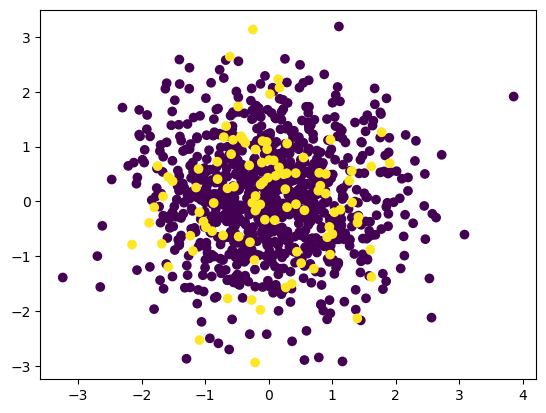

In [19]:
import matplotlib.pyplot as plt
plt.scatter(df["feature_1"], df["feature_2"], c=df["target"])

In [20]:
from imblearn.over_sampling import SMOTE

In [21]:
oversample = SMOTE()

In [33]:
(X,y) = oversample.fit_resample(df[["feature_1", "feature_2"]], df["target"]) #ikiye bölerek veriyor sonrasında concat gerekir.

In [34]:
type(X)

pandas.core.frame.DataFrame

In [38]:
oversample_df = pd.concat([X,y], axis=1)

In [41]:
oversample_df["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

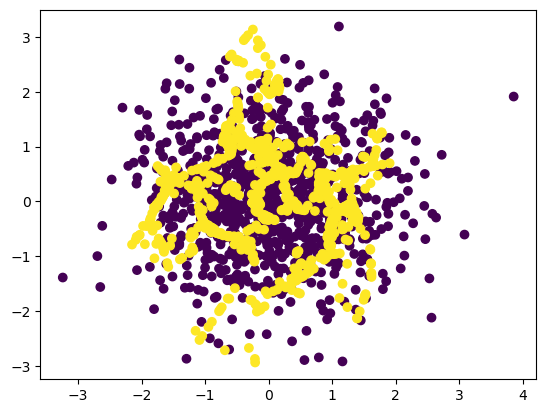

In [42]:
plt.scatter(oversample_df["feature_1"], oversample_df["feature_2"], c=oversample_df["target"])